# Supply Chain Logistics — Exploratory Analysis

Exploration of the ML-ready delivery-delay dataset produced by the pipeline.

Run the pipeline first (see `docs/reproduction_guide.md`), then execute this
notebook top to bottom.

**Contents**
1. Load the ML-ready data
2. Target distribution (`is_delayed`, `delivery_delay`)
3. Carrier and route performance
4. Feature correlations with delay
5. Verify the train/test split is clean

In [1]:
import os
import sys

import pandas as pd
import polars as pl

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)

ML_READY = os.path.join(PROJECT_ROOT, "data", "ml_ready")
PROCESSED = os.path.join(PROJECT_ROOT, "data", "processed")

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

## 1. Load the ML-ready data

Read with Polars (fast scan of the Parquet) and keep a pandas copy for the
plotting helpers.

In [2]:
train_pl = pl.read_parquet(os.path.join(ML_READY, "train.parquet"))
test_pl = pl.read_parquet(os.path.join(ML_READY, "test.parquet"))

print(f"train: {train_pl.height:,} rows x {train_pl.width} cols")
print(f"test : {test_pl.height:,} rows x {test_pl.width} cols")

train = train_pl.to_pandas()
test = test_pl.to_pandas()
train.head()

train: 144,388 rows x 27 cols
test : 36,131 rows x 27 cols


,order_id,customer_id,order_date,quantity,unit_price,discount_rate,weight_kg,distance_km,promised_delivery_days,shipping_cost,shipping_cost_per_unit,route_efficiency_score,carrier_performance_score,seasonal_demand_index,warehouse_utilization,inventory_turnover,reorder_risk_score,carrier,shipping_mode,product_category,customer_segment,destination_region,distance_category,shipment_size_category,order_status,is_delayed,delivery_delay
0,ORD-0000001,20755,2018-01-31 22:56:00,1,327.75,0.04,2.344,4259.8,4,216.51,216.51,0.1194,0.4328,0.4351,NaN,0.0333,0.3758,FedEx,Standard Class,Sporting Goods,Consumer,Southeast Asia,Long-Haul,Small,COMPLETE,0,-1
1,ORD-0000002,19492,2018-01-13 12:27:00,1,327.75,0.05,1.373,5397.7,4,271.94,271.94,0.0902,0.4257,0.4351,NaN,1.2000,0.4432,UPS,Standard Class,Sporting Goods,Consumer,South Asia,Long-Haul,Small,PENDING,1,1
2,ORD-0000003,19491,2018-01-13 12:06:00,1,327.75,0.06,2.590,3987.9,4,203.28,203.28,0.0833,0.4231,0.4351,NaN,1.2000,0.3427,Maersk Line,Standard Class,Sporting Goods,Consumer,South Asia,Long-Haul,Small,CLOSED,0,0
3,ORD-0000004,19490,2018-01-13 11:45:00,1,327.75,0.07,2.122,5322.6,4,269.31,269.31,0.1479,0.4297,0.4351,NaN,1.2000,0.4015,DB Schenker,Standard Class,Sporting Goods,Home Office,Oceania,Long-Haul,Small,COMPLETE,0,-1
4,ORD-0000006,19488,2018-01-13 11:03:00,1,327.75,0.10,2.929,10402.6,4,524.52,524.52,0.1445,0.4328,0.4351,NaN,1.2000,0.3758,FedEx,Standard Class,Sporting Goods,Consumer,Oceania,International,Small,CANCELED,1,2


## 2. Target distribution

The pipeline emits both targets named in the brief: `is_delayed` (binary
classification) and `delivery_delay` in days (regression).

In [3]:
balance = train["is_delayed"].value_counts(normalize=True).sort_index()
print("is_delayed class balance (train):")
print(balance.rename({0: "on time", 1: "delayed"}).round(4))

print("\ndelivery_delay (days) describe:")
train["delivery_delay"].describe().round(3)

is_delayed class balance (train):
is_delayed
on time    0.4275
delayed    0.5725
Name: proportion, dtype: float64

delivery_delay (days) describe:


count    144388.000
mean          0.566
std           1.494
min          -2.000
25%           0.000
50%           1.000
75%           1.000
max           4.000
Name: delivery_delay, dtype: float64

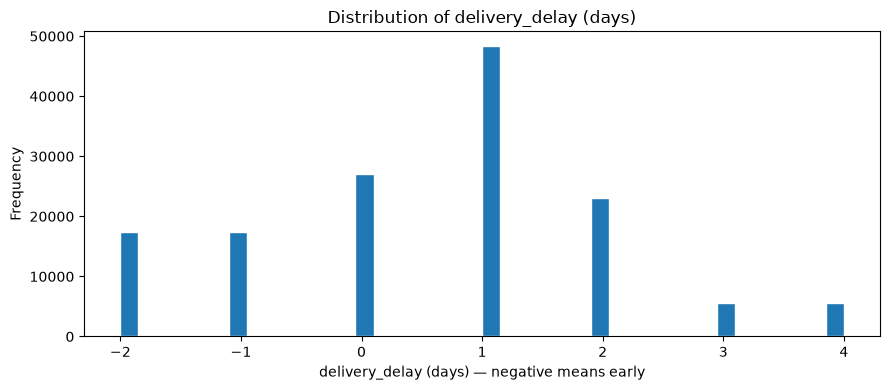

In [4]:
ax = train["delivery_delay"].plot(
    kind="hist", bins=40, figsize=(9, 4),
    title="Distribution of delivery_delay (days)", edgecolor="white",
)
ax.set_xlabel("delivery_delay (days) — negative means early")
ax.figure.tight_layout()

## 3. Carrier and route performance

Group-bys done in Polars to show the same aggregation the Spark stage
performs at scale.

In [5]:
carrier_perf = (
    train_pl
    .group_by("carrier")
    .agg([
        pl.len().alias("orders"),
        (1 - pl.col("is_delayed").mean()).round(4).alias("on_time_rate"),
        pl.col("delivery_delay").mean().round(3).alias("avg_delay_days"),
        pl.col("shipping_cost_per_unit").mean().round(2).alias("avg_cost_per_unit"),
    ])
    .sort("on_time_rate", descending=True)
)
carrier_perf

carrier,orders,on_time_rate,avg_delay_days,avg_cost_per_unit
str,u32,f64,f64,f64
"""FedEx""",24339,0.4343,0.544,210.09
"""DB Schenker""",23772,0.4309,0.557,211.15
"""Local Courier Co""",23951,0.4263,0.579,210.62
"""DHL Express""",23917,0.4253,0.572,210.94
"""UPS""",24058,0.4243,0.568,210.57
"""Maersk Line""",24351,0.424,0.578,210.26


In [6]:
by_distance = (
    train_pl
    .group_by("distance_category")
    .agg([
        pl.len().alias("orders"),
        pl.col("delivery_delay").mean().round(3).alias("avg_delay_days"),
        pl.col("route_efficiency_score").mean().round(3).alias("avg_route_efficiency"),
    ])
    .sort("avg_delay_days", descending=True)
)
by_distance

distance_category,orders,avg_delay_days,avg_route_efficiency
str,u32,f64,f64
"""Regional""",18230,0.59,0.036
"""Local""",5815,0.574,0.007
"""International""",72301,0.567,0.257
"""Long-Haul""",48042,0.556,0.115


## 4. Which features move with delay?

Numeric correlation against the regression target. Useful as a first pass at
feature selection before modelling.

In [7]:
numeric = train.select_dtypes("number").drop(columns=["is_delayed"], errors="ignore")
corr = (
    numeric.corr(numeric_only=True)["delivery_delay"]
    .drop(labels=["delivery_delay"], errors="ignore")
    .sort_values(key=abs, ascending=False)
)
corr.round(3).to_frame("corr_with_delivery_delay")

,corr_with_delivery_delay
promised_delivery_days,-0.361
route_efficiency_score,-0.261
reorder_risk_score,0.024
carrier_performance_score,-0.008
unit_price,-0.004
discount_rate,0.003
quantity,0.003
shipping_cost_per_unit,-0.003
inventory_turnover,-0.003
weight_kg,0.003


## 5. Split sanity checks

The split is keyed on an md5 hash of `order_id`, so it must be stable and
leak-free. Both checks below should pass.

In [8]:
overlap = set(train["order_id"]) & set(test["order_id"])
print(f"order_id overlap between train and test: {len(overlap)}  (expected 0)")

test_share = len(test) / (len(train) + len(test))
print(f"test share: {test_share:.4f}  (target ~0.20)")

print("\nclass balance train vs test:")
pd.DataFrame({
    "train": train["is_delayed"].value_counts(normalize=True).sort_index().round(4),
    "test": test["is_delayed"].value_counts(normalize=True).sort_index().round(4),
})

order_id overlap between train and test: 0  (expected 0)
test share: 0.2002  (target ~0.20)

class balance train vs test:


,train,test
is_delayed,,
0,0.4275,0.4259
1,0.5725,0.5741
